# Grunnmodell: hierarkisk multi-head CNN uten augmentering på preprosesserte bilder


### Imports og maskinvareoppsett

Importerer bibliotekene som brukes videre i notebooken og gjør et enkelt GPU-oppsett for TensorFlow. XLA holdes av, og dersom en GPU er tilgjengelig settes `memory_growth` for å redusere risikoen for at TensorFlow reserverer all videominne ved oppstart.


In [1]:

# 0) Imports
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

tf.config.optimizer.set_jit(False)  # disable XLA autoclustering

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


2026-03-13 17:34:03.520458: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 17:34:03.547777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 17:34:04.129557: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



### Prosjektstruktur, konstanter og filstier til preprosesserte data

Definerer sentrale konstanter for eksperimentet, lokaliserer prosjektroten og setter opp stier mot de **preprosesserte** CSV-filene og bildemappene.


In [2]:

# 1) Konstanter og prosjektstruktur
SEED = 42
IMG_SIZE = (300, 300)   # Må matche størrelsen som ble eksportert i baseline_preprocessing
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "datasplitt_preprocessed").exists():
            return p
        if (p / "datasplitt" / "train.csv").exists():
            return p
    raise FileNotFoundError("Fant ikke prosjektrot med datasplitt_preprocessed/ eller datasplitt/train.csv")

PROJECT_ROOT = find_project_root(Path.cwd())
TRAIN_CSV = PROJECT_ROOT / "datasplitt_preprocessed" / "train_processed.csv"
VAL_CSV   = PROJECT_ROOT / "datasplitt_preprocessed" / "val_processed.csv"
TEST_CSV  = PROJECT_ROOT / "datasplitt_preprocessed" / "test_processed.csv"
IMG_ROOT  = PROJECT_ROOT / "datasett_preprocessed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TEST_CSV:", TEST_CSV)
print("IMG_ROOT:", IMG_ROOT)


PROJECT_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions
TRAIN_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/train_processed.csv
VAL_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/val_processed.csv
TEST_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/test_processed.csv
IMG_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed



### Les inn preprosesserte splitter og kontroller grunnstrukturen

Leser inn `train`, `val` og `test` fra de nye CSV-filene. Notebooken forventer at hver rad peker til et ferdig lagret bilde via kolonnen `processed_image`. For robusthet brukes `image` som reserve hvis denne kolonnen ikke finnes.


In [3]:

# 2) Last split CSV-er
if not TRAIN_CSV.exists() or not VAL_CSV.exists() or not TEST_CSV.exists():
    raise FileNotFoundError("Fant ikke de preprosesserte CSV-filene. Kjør baseline_preprocessing.ipynb først.")

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n[{name}] shape={df.shape}")
    print(df.columns.tolist())
    display(df.head(2))



[train] shape=(3766, 14)
['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key', 'w_lvl2', 'y_lvl1', 'w_lvl1', 'y_lvl2', 'processed_image']


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key,w_lvl2,y_lvl1,w_lvl1,y_lvl2,processed_image
0,White,Egenprodusert/non-tesla/dark/IMG_1954.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark,0.0,0,1.0,0,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg
1,Black/Dark gray,Egenprodusert/Tesla/daylight/IMG_1802.jpg,Light,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Light,1.0,1,1.0,0,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg



[val] shape=(807, 14)
['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key', 'w_lvl2', 'y_lvl1', 'w_lvl1', 'y_lvl2', 'processed_image']


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key,w_lvl2,y_lvl1,w_lvl1,y_lvl2,processed_image
0,Light gray/Silver,Egenprodusert/non-tesla/dark/IMG_1951.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark,0.0,0,1.0,0,val/Egenprodusert/non-tesla/dark/IMG_1951.jpg
1,Black/Dark gray,Egenprodusert/non-tesla/dark/20260303_18154471...,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark,0.0,0,1.0,0,val/Egenprodusert/non-tesla/dark/20260303_1815...



[test] shape=(807, 14)
['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key', 'w_lvl2', 'y_lvl1', 'w_lvl1', 'y_lvl2', 'processed_image']


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key,w_lvl2,y_lvl1,w_lvl1,y_lvl2,processed_image
0,Black/Dark gray,Egenprodusert/non-tesla/dark/IMG_4844.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark,0.0,0,1.0,0,test/Egenprodusert/non-tesla/dark/IMG_4844.jpg
1,Light gray/Silver,Egenprodusert/Tesla/dark/%~n1-0.jpg,Dark,3 2024–nå,internal,2024–nå,Tesla,3 2024–nå,Tesla|3 2024–nå|Dark,1.0,1,1.0,1,test/Egenprodusert/Tesla/dark/%~n1-0.jpg


### Velg bildefilsti-kolonne og valider ferdige treningskolonner

In [4]:
# 3) Velg sti-kolonne og valider ferdige kolonner
PATH_COL = "processed_image" if "processed_image" in train_df.columns else "image"
print("Bruker bildefilsti-kolonne:", PATH_COL)

required_cols = [
    PATH_COL,
    "lvl1",
    "lvl2",
    "lighting",
    "y_lvl1",
    "y_lvl2",
    "w_lvl2",
]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"{name}_df mangler forventede kolonner {missing}. "
            "Kjør baseline_preprocessing.ipynb på nytt og eksporter oppdaterte CSV-er."
        )

# w_lvl1 kan enten finnes ferdig eller settes fast til 1.0 her
for df in (train_df, val_df, test_df):
    if "w_lvl1" not in df.columns:
        df["w_lvl1"] = 1.0

sample_paths = [str(IMG_ROOT / p) for p in train_df[PATH_COL].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

# Antall lvl2-klasser hentes direkte fra ferdig encoded train-split
num_lvl2 = int(train_df.loc[train_df["w_lvl2"] > 0, "y_lvl2"].max()) + 1
lvl2_classes = (
    train_df.loc[train_df["w_lvl2"] > 0, ["lvl2", "y_lvl2"]]
    .drop_duplicates()
    .sort_values("y_lvl2")["lvl2"]
    .astype(str)
    .tolist()
)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

display(train_df[[PATH_COL, "lvl1", "lvl2", "lighting", "y_lvl1", "y_lvl2", "w_lvl2"]].head())

Bruker bildefilsti-kolonne: processed_image
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/non-tesla/dark/IMG_1954.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/Tesla/daylight/IMG_1802.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/Tesla/dark/IMG_3834.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/non-tesla/low-light/IMG_4576.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Eksternt/non-tesla/daylight/0476_03052.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenproduser

,processed_image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg,Other,NaN,Dark,0,0,0.0
1,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg,Tesla,3 2017–2023,Light,1,0,1.0
2,train/Egenprodusert/Tesla/dark/IMG_3834.jpg,Tesla,X,Dark,1,4,1.0
3,train/Egenprodusert/non-tesla/low-light/IMG_45...,Other,NaN,Medium,0,0,0.0
4,train/Eksternt/non-tesla/daylight/0476_03052.jpg,Other,NaN,Light,0,0,0.0


### Enkel bildeinnlesing og datasett-pipeline uten augmentering

Leser ferdig preprosesserte bilder og bygger `tf.data`-datasett for trening, validering og test. I denne notebooken brukes ingen dataaugmentering, slik at endringer i resultatene kan knyttes til modellarkitekturen og ikke til inputtransformasjoner.

In [5]:
def decode_ready_image(path: tf.Tensor) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.ensure_shape(img, [IMG_SIZE[0], IMG_SIZE[1], 3])
    return img


def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = np.array([str(IMG_ROOT / p) for p in df[PATH_COL].astype(str).to_list()], dtype=np.str_)
    y1 = df["y_lvl1"].to_numpy(np.int32)
    y2 = df["y_lvl2"].to_numpy(np.int32)
    w1 = df["w_lvl1"].to_numpy(np.float32)
    w2 = df["w_lvl2"].to_numpy(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, y1, y2, w1, w2))

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(df), 5000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    def _map(path, y1, y2, w1, w2):
        img = decode_ready_image(path)
        y = {"lvl1": y1, "lvl2": y2}
        sw = {"lvl1": w1, "lvl2": w2}
        return img, y, sw

    # Behold en moderat pipeline-konfigurasjon for stabil trening på GPU.
    ds = ds.map(_map, num_parallel_calls=4)

    if not training:
        ds = ds.cache()

    ds = ds.batch(BATCH_SIZE).prefetch(2)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for x, y, sw in train_ds.take(1):
    print("x:", x.shape, x.dtype)
    print("y lvl1:", y["lvl1"].shape, "y lvl2:", y["lvl2"].shape)
    print("sw lvl1:", sw["lvl1"].shape, "sw lvl2:", sw["lvl2"].shape)


I0000 00:00:1773419655.603185   19360 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21509 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


x: (16, 300, 300, 3) <dtype: 'float32'>
y lvl1: (16,) y lvl2: (16,)
sw lvl1: (16,) sw lvl2: (16,)


2026-03-13 17:34:16.194413: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Modell og logging

De neste blokkene setter opp eksperimentlogging og definerer grunnmodellen som brukes som utgangspunkt for videre arkitektureksperimenter.

### AIM-logging

Oppretter et eksperimentnavn for AIM slik at treningskurver og metrikkserier kan logges og sammenlignes mellom ulike arkitekturvarianter.

In [6]:
from aim.tensorflow import AimCallback
import datetime

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
EXPERIMENT_NAME = "baseline_architecture"
print("Experiment name:", EXPERIMENT_NAME)

aim_callback = AimCallback(
    repo=str(PROJECT_ROOT),                 # -> legger .aim i prosjektroten
    experiment=EXPERIMENT_NAME,
    log_system_params=False,                
)

print("Aim repo:", PROJECT_ROOT / ".aim")
print("Aim experiment:", EXPERIMENT_NAME)

Experiment name: baseline_architecture
Aim repo: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.aim
Aim experiment: baseline_architecture


### Bygg grunnmodellen

Oppretter modellen via `build_model()` og skriver ut et sammendrag av arkitekturen. Denne versjonen fungerer som en ren referanse uten augmentering, slik at videre endringer kan rettes mot selve modellarkitekturen.

In [7]:
def build_model():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    x = keras.layers.Dense(128, activation="relu")(x)

    out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
    out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

    model = keras.Model(
        inputs=inputs,
        outputs={"lvl1": out_lvl1, "lvl2": out_lvl2},
        name="baseline_hierarchical_cnn"
    )

    opt = keras.optimizers.Adam(learning_rate=6e-4)

    model.compile(
        optimizer=opt,
        loss={
            "lvl1": keras.losses.BinaryCrossentropy(),
            "lvl2": keras.losses.SparseCategoricalCrossentropy(),
        },
        metrics={
            "lvl1": [keras.metrics.BinaryAccuracy(name="acc")],
        },
        weighted_metrics={
            "lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
        },
        jit_compile=False,
    )
    return model

model = build_model()
model.summary()

Model: "baseline_hierarchical_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 300, 300,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 300, 300,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 300, 300,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 150, 150,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 150, 150,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 150, 150,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 75, 75,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 75, 75,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_4[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl1 (Dense)        │ (None, 1)         │        129 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl2 (Dense)        │ (None, 7)         │        903 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,968 (613.16 KB)

 Trainable params: 156,968 (613.16 KB)

 Non-trainable params: 0 (0.00 B)

### Modellarkitektur og kompilering

### Trening med checkpoint per epoch

Trener modellen i et fast antall epoker og lagrer vekter for hver epoch under `checkpoints/<RUN_TAG>/`. Den siste modellen evalueres kort på valideringssettet etter `fit()`, men endelig modellvalg gjøres senere ved eksplisitt epoch-sammenligning på valideringssettet.

In [8]:
# 10) Train
EPOCHS = 100
from pathlib import Path

RUN_TAG = "baseline_architecture"
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=str(ckpt_dir / "epoch_{epoch:02d}.weights.h5"),
    save_weights_only=True,
    save_best_only=False,   # vi vil kunne evaluere alle epoker i etterkant
    verbose=0
)

callbacks = [
    aim_callback,
    checkpoint_callback,
    # evt. EarlyStopping(...)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Eval (val; lvl2 maskert via sample_weight) – siste epoch, ikke beste:")
print(model.evaluate(val_ds, return_dict=True))

# FINAL Eval på test skal ikke kjøres her.
# Den skal først kjøres etter at beste epoch er valgt på valideringssettet.

Epoch 1/100


2026-03-13 17:34:28.930119: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


236/236 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 1.4412 - lvl1_acc: 0.5712 - lvl1_loss: 0.6826 - lvl2_acc: 0.3741 - lvl2_loss: 0.7600 - val_loss: 1.4169 - val_lvl1_acc: 0.5762 - val_lvl1_loss: 0.6811 - val_lvl2_acc: 0.3743 - val_lvl2_loss: 0.7374
Epoch 2/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 1.4115 - lvl1_acc: 0.5738 - lvl1_loss: 0.6796 - lvl2_acc: 0.3759 - lvl2_loss: 0.7318 - val_loss: 1.4056 - val_lvl1_acc: 0.5762 - val_lvl1_loss: 0.6773 - val_lvl2_acc: 0.3743 - val_lvl2_loss: 0.7304
Epoch 3/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 1.3898 - lvl1_acc: 0.5820 - lvl1_loss: 0.6676 - lvl2_acc: 0.3741 - lvl2_loss: 0.7241 - val_loss: 1.3676 - val_lvl1_acc: 0.5923 - val_lvl1_loss: 0.6537 - val_lvl2_acc: 0.3743 - val_lvl2_loss: 0.7160
Epoch 4/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 1.3710 - lvl1_acc: 0.5860 - lvl1_loss: 0.6565 - lvl2_acc: 0.3741 - lvl2_loss: 0.7142 - val_loss: 1.3573 - val_lvl1_acc: 0.6270 - val_lvl1_loss: 0.6449 - val_lvl2_acc: 0.

## Valideringsbasert epoch-valg og sluttevaluering

Etter trening settes hvilken datasplitt som skal brukes til modellvalg og evaluering. Videre defineres hjelpefunksjoner for nivå 1 og nivå 2, før alle lagrede checkpoints sammenlignes på valideringssettet for å velge én beste epoch. Til slutt kjøres og lagres de endelige nivå 1- og nivå 2-evalueringene for den valgte modellen.

### Velg evalueringssplit

Setter hvilken split som skal brukes i den videre evalueringen. Under modellutvikling brukes normalt `val`, mens samme blokker senere kan kjøres på `test` for endelig rapportering.

In [14]:
EVAL_SPLIT = "val"
RUN_TAG = "baseline_architecture"

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print(f"Evaluerer split: {EVAL_SPLIT} | n = {len(eval_df)}")
print(f"Checkpoint-mappe: checkpoints/{RUN_TAG}")

Evaluerer split: val | n = 807
Checkpoint-mappe: checkpoints/baseline_architecture



### Hjelpefunksjoner for nivå 1-evaluering

Definerer funksjoner for prediksjon og evaluering av `lvl1`. Prediksjonene kjøres på de ferdig preprosesserte bildene, og blokken beregner metrikkene både for **Total** og per lyskategori, samt 2×2-forvirringsmatriser som senere brukes i visualisering og lagring.


In [15]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score
)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd


def predict_heads(model, df, batch_size=16):
    """
    Predikerer begge hoder manuelt i batcher uten model.predict på tf.data.
    Returnerer:
      p1 = lvl1-prediksjoner (sigmoid)
      p2 = lvl2-prediksjoner (softmax)
    """
    paths = [str(IMG_ROOT / p) for p in df[PATH_COL].astype(str).to_list()]

    lvl1_parts = []
    lvl2_parts = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]

        imgs = []
        for path in batch_paths:
            img = decode_ready_image(tf.constant(path))
            imgs.append(img)

        x = tf.stack(imgs, axis=0)   # [B, H, W, C]
        preds = model(x, training=False)

        lvl1_parts.append(preds["lvl1"].numpy().reshape(-1))
        lvl2_parts.append(preds["lvl2"].numpy())

    p1 = np.concatenate(lvl1_parts, axis=0)
    p2 = np.concatenate(lvl2_parts, axis=0)
    return p1, p2


def plot_cm_2x2(cm, title, save_path=None, ax=None):
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.0))
        created_fig = True

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

    if created_fig and save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=160)
        plt.show()


def _lvl1_metrics_row(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    tnr = tn / (tn + fp) if (tn + fp) else np.nan

    row = {
        "lighting": name,
        "n_total": int(len(y_true)),
        "n_other": int((y_true == 0).sum()),
        "n_tesla": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "TPR": tpr,
        "TNR": tnr,
        "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
        "lvl1_acc": accuracy_score(y_true, y_pred),
        "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(y_true),
    }
    return row, cm


def eval_lvl1_by_lighting(
    model,
    df,
    lighting_col="lighting",
    threshold=0.5,
    lighting_order=("Light", "Medium", "Dark"),
    batch_size=16,
):
    rows = []
    cms = {}

    p1_all, _ = predict_heads(model, df, batch_size=batch_size)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)

    total_row, total_cm = _lvl1_metrics_row("Total", y_true_all, y_pred_all)
    rows.append(total_row)
    cms["Total"] = total_cm

    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue

        y_true = y_true_all[mask]
        y_pred = y_pred_all[mask]

        row, cm = _lvl1_metrics_row(light, y_true, y_pred)
        rows.append(row)
        cms[light] = cm

    return pd.DataFrame(rows), cms

### Hjelpefunksjoner for nivå 2-evaluering

Definerer tilsvarende evalueringslogikk for `lvl2`, men kun på Tesla-rader. Her beregnes totalmetrikker, metrikk per lyskategori, klassevise precision/recall/F1-verdier og normaliserte forvirringsmatriser for videre analyse.

In [16]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_cm_norm(cm_norm, labels, title, save_path=None, max_classes=30):
    plt.figure(figsize=(7.0, 6.0))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()


def _lvl2_metrics_row(name, y_true, y_pred):
    counts = np.bincount(y_true, minlength=num_lvl2)
    maj_acc = counts.max() / len(y_true) if len(y_true) else np.nan

    row = {
        "lighting": name,
        "n_tesla": int(len(y_true)),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": maj_acc,
    }

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    return row, cm, cm_norm


def eval_lvl2(
    model,
    df,
    lighting_col="lighting",
    lighting_order=("Light", "Medium", "Dark"),
    topn=8,
    batch_size=16,
):
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    if tesla_df.empty:
        raise ValueError("Ingen Tesla-rader i eval_df – kan ikke evaluere lvl2.")

    _, p2 = predict_heads(model, tesla_df, batch_size=batch_size)

    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    total_row, cm, cm_norm = _lvl2_metrics_row("Total", y_true, y_pred)
    df_overall = pd.DataFrame([{
        "n_tesla": total_row["n_tesla"],
        "lvl2_acc": total_row["lvl2_acc"],
        "lvl2_bal_acc": total_row["lvl2_bal_acc"],
        "lvl2_f1_macro": total_row["lvl2_f1_macro"],
        "lvl2_maj_acc": total_row["lvl2_maj_acc"],
    }])

    rows = [total_row]
    cm_norm_by_light = {"Total": cm_norm}

    for light in lighting_order:
        mask = (tesla_df[lighting_col].to_numpy() == light)
        if mask.sum() == 0:
            continue

        y_t = y_true[mask]
        y_p = y_pred[mask]

        row, _, cm_l_norm = _lvl2_metrics_row(light, y_t, y_p)
        rows.append(row)
        cm_norm_by_light[light] = cm_l_norm

    df_by_light = pd.DataFrame(rows)

    support_tbl = (
        tesla_df.groupby(["lvl2", lighting_col]).size()
        .unstack(lighting_col, fill_value=0)
        .reindex(index=lvl2_classes, fill_value=0)
    )
    support_tbl["Total"] = support_tbl.sum(axis=1)
    support_tbl.loc["Total"] = support_tbl.sum(axis=0)

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0
    )
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm[i].sum())))

    df_confusions = (
        pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"])
        .sort_values(["rate", "support_true"], ascending=[False, False])
        .head(5)
    )

    return df_overall, df_by_light, support_tbl, df_per_class, cm_norm, df_confusions, cm_norm_by_light

### Velg beste epoch fra valideringssettet

Laster inn alle lagrede checkpoints, evaluerer dem på valgt split og rangerer epokene etter en samlet score:

- `0.5 * lvl1_total_f1_macro`
- `0.5 * lvl2_total_f1_macro`

Den beste epoken lastes deretter inn på nytt i `model`, slik at de neste evalueringsblokkene bruker én konsistent modell.

In [17]:
import re
import gc
import tensorflow as tf

# Finn lagrede checkpoints fra treningen
RUN_TAG = "baseline_architecture"
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_files = sorted(ckpt_dir.glob("epoch_*.weights.h5"))

print("Bruker checkpoint-mappe:", ckpt_dir)
print("Antall checkpoints:", len(ckpt_files))
print("Siste checkpoint:", ckpt_files[-1] if ckpt_files else None)

if not ckpt_files:
    raise FileNotFoundError(f"Fant ingen checkpoints i {ckpt_dir}")

rows = []

for ckpt in ckpt_files:
    tf.keras.backend.clear_session()
    gc.collect()

    # Bygg samme arkitektur på nytt
    tmp_model = build_model()
    tmp_model.load_weights(str(ckpt))

    # Eval lvl1 -> hent Total F1
    df_lvl1_tmp, _ = eval_lvl1_by_lighting(
        tmp_model,
        eval_df,
        threshold=0.5,
        batch_size=16
    )
    lvl1_total_f1 = float(
        df_lvl1_tmp.loc[df_lvl1_tmp["lighting"] == "Total", "lvl1_f1_macro"].iloc[0]
    )

    # Eval lvl2 -> hent Total F1
    _, df_lvl2_tmp, _, _, _, _, _ = eval_lvl2(
        tmp_model,
        eval_df,
        batch_size=16
    )
    lvl2_total_f1 = float(
        df_lvl2_tmp.loc[df_lvl2_tmp["lighting"] == "Total", "lvl2_f1_macro"].iloc[0]
    )

    # 50/50 samlet score
    total_score = 0.5 * lvl1_total_f1 + 0.5 * lvl2_total_f1

    epoch_num = int(re.search(r"epoch_(\d+)", ckpt.name).group(1))

    rows.append({
        "epoch": epoch_num,
        "lvl1_total_f1_macro": lvl1_total_f1,
        "lvl2_total_f1_macro": lvl2_total_f1,
        "score_50_50": total_score,
        "checkpoint": str(ckpt),
    })

    del tmp_model
    gc.collect()

epoch_scores = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(epoch_scores)

best_row = epoch_scores.sort_values("score_50_50", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])
best_ckpt = best_row["checkpoint"]

print(f"Best epoch: {best_epoch}")
print(f"Best checkpoint: {best_ckpt}")
print(f"Lvl1 Total F1: {best_row['lvl1_total_f1_macro']:.4f}")
print(f"Lvl2 Total F1: {best_row['lvl2_total_f1_macro']:.4f}")
print(f"50/50 score:   {best_row['score_50_50']:.4f}")

# Last inn beste epoch i modellen som skal brukes videre
tf.keras.backend.clear_session()
gc.collect()

model = build_model()
model.load_weights(best_ckpt)

print(f"Modellen er nå lastet med beste epoch = {best_epoch}")

Bruker checkpoint-mappe: checkpoints/baseline_architecture
Antall checkpoints: 100
Siste checkpoint: checkpoints/baseline_architecture/epoch_99.weights.h5


/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 varia

,epoch,lvl1_total_f1_macro,lvl2_total_f1_macro,score_50_50,checkpoint
0,1,0.365566,0.077812,0.221689,checkpoints/baseline_architecture/epoch_01.wei...
1,2,0.365566,0.077812,0.221689,checkpoints/baseline_architecture/epoch_02.wei...
2,3,0.461285,0.077812,0.269548,checkpoints/baseline_architecture/epoch_03.wei...
3,4,0.575967,0.077812,0.326889,checkpoints/baseline_architecture/epoch_04.wei...
4,5,0.620228,0.077977,0.349103,checkpoints/baseline_architecture/epoch_05.wei...
5,6,0.616998,0.077812,0.347405,checkpoints/baseline_architecture/epoch_06.wei...
6,7,0.688327,0.077812,0.383070,checkpoints/baseline_architecture/epoch_07.wei...
7,8,0.675138,0.083665,0.379402,checkpoints/baseline_architecture/epoch_08.wei...
8,9,0.688546,0.077812,0.383179,checkpoints/baseline_architecture/epoch_09.wei...
9,10,0.710110,0.084281,0.397196,checkpoints/baseline_architecture/epoch_10.wei...


Best epoch: 79
Best checkpoint: checkpoints/baseline_architecture/epoch_79.weights.h5
Lvl1 Total F1: 0.9030
Lvl2 Total F1: 0.6003
50/50 score:   0.7517
Modellen er nå lastet med beste epoch = 79


/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Kjør og lagre nivå 1-resultater

Kjører endelig `lvl1`-evaluering for den modellen som nå er lastet inn, lagrer metrikk-tabellen til disk og produserer forvirringsmatriser for `Light`, `Medium` og `Dark`.

,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Total,807,465,342,416,49,28,314,0.918129,0.894624,0.906376,0.904585,0.903036,0.576208
1,Light,442,282,160,264,18,20,140,0.875000,0.936170,0.905585,0.914027,0.906683,0.638009
2,Medium,185,93,92,74,19,4,88,0.956522,0.795699,0.876110,0.875676,0.874960,0.502703
3,Dark,180,90,90,78,12,4,86,0.955556,0.866667,0.911111,0.911111,0.910935,0.500000


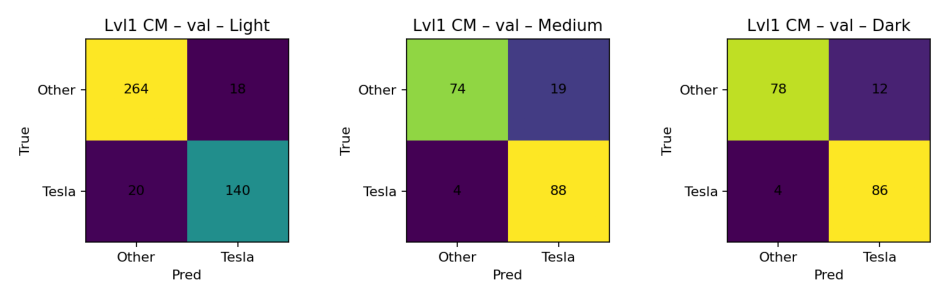

In [ ]:
import matplotlib.pyplot as plt
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))

for ax, light in zip(axes, ("Light", "Medium", "Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)

fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160)
plt.show()

### Kjør og lagre nivå 2-resultater

Kjører tilsvarende sluttevaluering for `lvl2`, lagrer metrikk per lyskategori, klassevise PR/F1-resultater og de vanligste forvekslingene, og visualiserer normaliserte forvirringsmatriser for Tesla-underklassene.

,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,Total,342,0.614035,0.612006,0.600345,0.374269
1,Light,160,0.631250,0.623864,0.603291,0.362500
2,Medium,92,0.586957,0.395918,0.399682,0.380435
3,Dark,90,0.611111,0.552948,0.519768,0.388889


,class_id,class,support,precision,recall,f1
0,0,3 2017–2023,51,0.367347,0.352941,0.360000
3,3,S 2016–nå,20,0.423077,0.550000,0.478261
4,4,X,41,0.766667,0.560976,0.647887
5,5,Y 2020–2024,128,0.650794,0.640625,0.645669
1,1,3 2024–nå,37,0.568182,0.675676,0.617284
2,2,S 2012–2015,16,0.578947,0.687500,0.628571
6,6,Y 2025-nå,49,0.833333,0.816327,0.824742


,true,pred,rate,support_true
0,3 2017–2023,Y 2020–2024,0.450980,51
3,S 2016–nå,S 2012–2015,0.200000,20
4,X,Y 2020–2024,0.195122,41
1,3 2024–nå,Y 2020–2024,0.189189,37
5,Y 2020–2024,3 2017–2023,0.179688,128


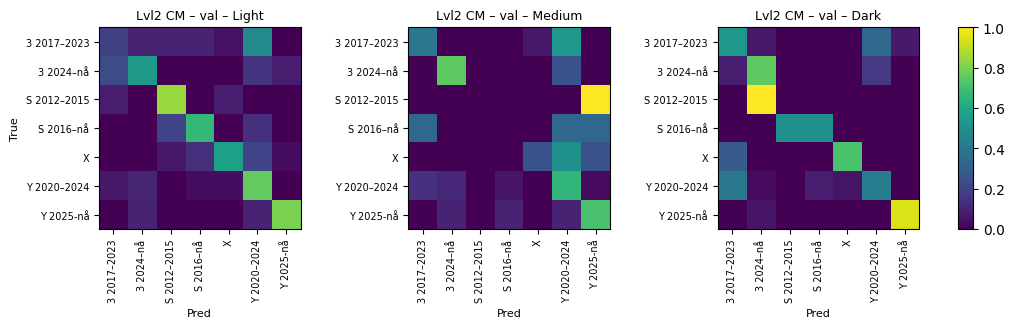

In [19]:

out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_overall, df_lvl2_by_light, support_tbl, df_lvl2_per_class, cm_norm, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df)


df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")


display(df_lvl2_by_light)
display(df_lvl2_per_class.head(10))
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue

    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)

    ax.set_xticks(range(num_lvl2))
    ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2))
    ax.set_yticklabels(lvl2_classes, fontsize=7)

    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)

cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160)
plt.show()